In [1]:
!pip install --upgrade scikit-learn==1.4 --no-cache-dir
!pip install cmaes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 173.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        fname=os.path.join(dirname, filename)
        print(fname)
        if "sub" in filename:
            df_sub=pd.read_csv(fname)
        elif "train" in filename:
            df_train=pd.read_csv(fname)
        elif "test" in filename:
            df_test=pd.read_csv(fname)
        else:
            df_origin=pd.read_csv(fname)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e3/sample_submission.csv
/kaggle/input/playground-series-s5e3/train.csv
/kaggle/input/playground-series-s5e3/test.csv


In [3]:
import pandas as pd
import numpy as np
from functools import partial
from copy import deepcopy
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Import libraries for gradient boosting
import optuna
from optuna.samplers import CmaEsSampler
from sklearn.base import BaseEstimator, TransformerMixin
import xgboost as xgb
import lightgbm as lgb


from sklearn.base import BaseEstimator, TransformerMixin
import xgboost as xgb
import lightgbm as lgb
import xgboost as xgb
import lightgbm as lgb

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.svm import NuSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from catboost import CatBoost, CatBoostRegressor, CatBoostClassifier
from catboost import Pool
from category_encoders import OneHotEncoder, OrdinalEncoder, CountEncoder, CatBoostEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold

from sklearn.metrics import log_loss, auc,roc_auc_score #root_mean_squared_error,
from sklearn.preprocessing import StandardScaler#,TargetEncoder
#from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import TimeSeriesSplit

from optuna.trial import TrialState

# Feature Engineering

In [4]:
#Add moving average 4
df_train['temp_mean_4'] = df_train['temparature'].rolling(window=4).mean().bfill().ffill()
df_train['windirection_mean_4'] = df_train['winddirection'].rolling(window=4).mean().bfill().ffill()
df_train['humidity_mean_4'] = df_train['humidity'].rolling(window=4).mean().bfill().ffill()
df_train['cloud_mean_4']=df_train['cloud'].rolling(window=4).mean().bfill().ffill()
df_train['windspeed_mean_4']=df_train['windspeed'].rolling(window=4).mean().bfill().ffill()

df_train['range_temp']=df_train['maxtemp']-df_train['mintemp']
df_train['range_temp_mean']=df_train['range_temp'].rolling(window=4).mean().bfill().ffill()

#do timeseries shift 
df_train['pressure_shift']=df_train['pressure'].shift(1).bfill()
df_train['humidity_shift']=df_train['humidity'].shift(1).bfill()
df_train['cloud_shift']=df_train['cloud'].shift(1).bfill()
df_train['pressure_shift2']=df_train['pressure'].shift(2).bfill()
df_train['humidity_shift2']=df_train['humidity'].shift(2).bfill()
df_train['cloud_shift2']=df_train['cloud'].shift(2).bfill()

In [5]:
df_test['temp_mean_4'] = df_test['temparature'].rolling(window=4).mean().bfill().ffill()
df_test['windirection_mean_4'] = df_test['winddirection'].rolling(window=4).mean().bfill().ffill()
df_test['humidity_mean_4'] = df_test['humidity'].rolling(window=4).mean().bfill().ffill()
df_test['cloud_mean_4']=df_test['cloud'].rolling(window=4).mean().bfill().ffill()
df_test['windspeed_mean_4']=df_test['windspeed'].rolling(window=4).mean().bfill().ffill()
df_test['range_temp']=df_test['maxtemp']-df_test['mintemp']
df_test['range_temp_mean']=df_test['range_temp'].rolling(window=4).mean().bfill().ffill()

#do timeseries shift 
df_test['pressure_shift']=df_test['pressure'].shift(1).bfill()
df_test['humidity_shift']=df_test['humidity'].shift(1).bfill()
df_test['cloud_shift']=df_test['cloud'].shift(1).bfill()
df_test['pressure_shift2']=df_test['pressure'].shift(2).bfill()
df_test['humidity_shift2']=df_test['humidity'].shift(2).bfill()
df_test['cloud_shift2']=df_test['cloud'].shift(2).bfill()

In [6]:
df_train['monthly_sin'] = np.sin(2 * np.pi * df_train['day'] / 30.44)
df_train['monthly_cos'] = np.cos(2 * np.pi * df_train['day'] / 30.44)
df_train['quarterly_sin'] = np.sin(2 * np.pi * df_train['day'] / 91.31)
df_train['quarterly_cos'] = np.cos(2 * np.pi * df_train['day'] / 91.31)
df_train['yearly_sin'] = np.sin(2 * np.pi * df_train['day'] / 365.25)
df_train['yearly_cos'] = np.cos(2 * np.pi * df_train['day'] / 365.25)

In [7]:
df_test['monthly_sin'] = np.sin(2 * np.pi * df_test['day'] / 30.44)
df_test['monthly_cos'] = np.cos(2 * np.pi * df_test['day'] / 30.44)
df_test['quarterly_sin'] = np.sin(2 * np.pi * df_test['day'] / 91.31)
df_test['quarterly_cos'] = np.cos(2 * np.pi * df_test['day'] / 91.31)
df_test['yearly_sin'] = np.sin(2 * np.pi * df_test['day'] / 365.25)
df_test['yearly_cos'] = np.cos(2 * np.pi * df_test['day'] / 365.25)

**Transformation**

In [8]:
df_test[df_test['winddirection'].isna()]

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,...,cloud_shift,pressure_shift2,humidity_shift2,cloud_shift2,monthly_sin,monthly_cos,quarterly_sin,quarterly_cos,yearly_sin,yearly_cos
517,2707,153,1007.8,32.9,30.6,28.9,22.0,65.0,75.0,8.2,...,87.0,1008.4,72.0,22.0,0.16438,0.986397,-0.892742,-0.450569,0.487847,-0.872929


In [9]:
df_test['winddirection']=df_test['winddirection'].fillna(100)

In [10]:
#Select columns to be dropped
#drop_cols=['id','temparature','winddirection','windspeed','range_temp']
drop_cols=['id']
df_train=df_train.drop(drop_cols,axis=1)
df_test=df_test.drop(drop_cols,axis=1)

In [11]:
sc = StandardScaler()
Y_train = df_train['rainfall']
X_train=sc.fit_transform(df_train.drop('rainfall',axis=1))
df_train_columns=df_train.drop('rainfall',axis=1).columns
X_test=sc.fit_transform(df_test)
# X_val = X_train[-730:,]
# Y_val = Y_train[-730:,]
# X_train=X_train[:-730,]
# Y_train=Y_train[:-730,]

# Define Model

In [12]:
class Classifier:
    def __init__(self, n_estimators=100, device="cpu", random_state=0,early_stop=100):
        self.n_estimators = n_estimators
        self.device = device
        self.random_state = random_state
        self.early_stop = early_stop
        self.models = self._define_model()
        self.len_models = len(self.models)

        
    def _define_model(self):
        
        xgb_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.05,
            'max_depth': 7,
            'subsample': 1.0,
            'colsample_bytree': 1.0,
            'n_jobs': -1,
            'eval_metric': 'logloss',
            'objective': 'binary:logistic',
            'verbosity': 0,
            'random_state': self.random_state,
        }
        if self.device == 'gpu':
            xgb_params['tree_method'] = 'gpu_hist'
            xgb_params['predictor'] = 'gpu_predictor'
        
        lgb_params = {
            'n_estimators': self.n_estimators,
            'max_depth': 7,
            'learning_rate': 0.05,
            'subsample': 0.20,
            'colsample_bytree': 0.56,
            'reg_alpha': 0.25,
            'reg_lambda': 5e-08,
            'objective': 'binary',
            'metric': 'binary_error',
            'boosting_type': 'gbdt',
            'early_stopping_rounds': self.early_stop,
            'device': self.device,
            'random_state': self.random_state,      
        }
        
        cb_params = {
            'iterations': self.n_estimators,
            'depth': 7,
            'learning_rate': 0.1,
            'l2_leaf_reg': 0.7,
            'random_strength': 0.2,
            'max_bin': 200,
            #'od_wait': 65,
            'one_hot_max_size': 70,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'Logloss',
            'loss_function': 'Logloss',
            'task_type': self.device.upper(),
            'random_state': self.random_state,
            'early_stopping_rounds':self.early_stop,
        }
        
        models = {
            'xgb': xgb.XGBClassifier(**xgb_params),
            'lgb': lgb.LGBMClassifier(**lgb_params),
            'cat': CatBoostClassifier(**cb_params),
            'lr': LogisticRegression(max_iter=500, random_state=self.random_state),
            'rf': RandomForestClassifier(n_estimators=1000, random_state=self.random_state),
            'hgb': HistGradientBoostingClassifier(max_iter=2000, random_state=self.random_state),
            'gbdt': GradientBoostingClassifier(n_estimators=1000, random_state=self.random_state),
            'svc': SVC(gamma="auto", probability=True),
            'knn': KNeighborsClassifier(n_neighbors=5),
            'mlp': MLPClassifier(random_state=self.random_state, max_iter=1000),
            'brf': BalancedRandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=self.random_state),
            'gpc': GaussianProcessClassifier(1.0 * RBF(1.0), random_state=self.random_state),
        }
        
        return models

# Optuna

In [13]:
class OptunaWeights:
    def __init__(self, random_state):
        self.study = None
        self.weights = None
        self.random_state = random_state

    def _objective(self, trial, y_true, y_preds):
        # Define the weights for the predictions from each model
        weights = [trial.suggest_float(f"weight{n}", 0, 1) for n in range(len(y_preds))]

        # Calculate the weighted prediction
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=weights)

        # Calculate the AUC score for the weighted prediction
        score = roc_auc_score(y_true, weighted_pred)
        return score

    def fit(self, y_true, y_preds, n_trials=1000):
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        self.study = optuna.create_study(sampler=sampler, study_name="OptunaWeights", direction='maximize')
        objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        self.study.optimize(objective_partial, n_trials=n_trials)
        self.weights = [self.study.best_params[f"weight{n}"] for n in range(len(y_preds))]

    def predict(self, y_preds):
        assert self.weights is not None, 'OptunaWeights error, must be fitted before predict'
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=self.weights)
        return weighted_pred

    def fit_predict(self, y_true, y_preds, n_trials=1000):
        self.fit(y_true, y_preds, n_trials=n_trials)
        return self.predict(y_preds)
    
    def weights(self):
        return self.weights
    

class ThresholdOptimizer:
    def __init__(self, y_true, y_preds, random_state):
        self.y_true = y_true
        self.y_preds = y_preds
        self.random_state = random_state
        self.sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        self.study = optuna.create_study(sampler=self.sampler, study_name="OptunaWeights", direction='maximize')
        self.objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        
    def _objective(self, trial, y_true, y_preds):
        threshold = trial.suggest_float("threshold", 0, 1)
        score = accuracy_score(y_true, np.where(y_preds > threshold, 1, 0))
        return score
        
    def run_optimization(self, n_trials=1000):
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        self.study.optimize(self.objective_partial, n_trials=n_trials)
        
    def get_best_threshold(self):
        return self.study.best_params["threshold"]

# Training

In [14]:
X=X_train
y=Y_train
sequence_length = 730
n_splits = 3
random_state = 42
n_estimators = 9999 # 9999
early_stopping_rounds = 100
verbose = False
device = 'cpu'

In [15]:


# Initialize an array for storing test predictions
test_predss = np.zeros(X_test.shape[0])
test_predss_onehot = []
test_predss_proba = []
ensemble_score = []
weights = []
trained_models = dict(zip(Classifier().models.keys(), [[] for _ in range(Classifier().len_models)]))


# Create custom split
custom_splits=[
    [(X[0:730],X[730:1460]),(y[0:730],y[730:1460])],
    [(X[0:1095],X[1095:1460]),(y[0:1095],y[1095:1460])],
    [(X[0:1460],X[1460:2190]),(y[0:1460],y[1460:2190])],
]


#tscv = TimeSeriesSplit(n_splits=n_splits)
#tscv.split(X_sequences)
#kf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=True)
for i, (Xtv, ytv) in enumerate(custom_splits):
    X_train_, X_val = Xtv 
    y_train_, y_val = ytv
        
    # Get a set of Regressor models
    classifier = Classifier(n_estimators, device, random_state,early_stopping_rounds)
    models = classifier.models
    categorical_columns=[]
    # Initialize lists to store oof and test predictions for each base model
    oof_preds = []
    test_preds = []
    
    # Loop over each base model and fit it to the training data, evaluate on validation data, and store predictions
    for name, model in models.items():
        if name == 'cat_label':
            train_pool = Pool(X_train_, y_train_, cat_features=categorical_columns)
            test_pool = Pool(X_val, y_val ,cat_features=categorical_columns)
            model.fit(train_pool, eval_set=[test_pool], early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        elif name == 'lgb_label':
            model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)], 
                      categorical_feature=categorical_columns, early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        elif name in ['xgb', 'lgb', 'cat']:
            if 'xgb' in name:
                model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)], early_stopping_rounds=early_stopping_rounds, verbose=verbose)
            else:
                model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)])
        else:
            model.fit(X_train_,y_train_) #model.fit(X_train_fillna.iloc[train_index], y_train_)
        
        
        if name in ['xgb', 'lgb', 'cat', 'cat_label', 'lgb_label']:
            test_pred = model.predict_proba(X_test)[:, 1]
            y_val_pred = model.predict_proba(X_val)[:, 1]
        else:
            test_pred = model.predict_proba(X_test)[:, 1]#model.predict_proba(X_test_fillna)[:, 1]
            y_val_pred = model.predict_proba(X_val)[:, 1]#model.predict_proba(X_train_fillna.iloc[val_index])[:, 1]
        
        score = roc_auc_score(y_val, y_val_pred)
        print(f'{name} model [FOLD-{i}] AUC: {score:.5f}')
        
        oof_preds.append(y_val_pred)
        test_preds.append(test_pred)
        trained_models[f'{name}'].append(deepcopy(model))
    
    # Use Optuna to find the best ensemble weights
    optweights = OptunaWeights(random_state=random_state)
    y_val_pred = optweights.fit_predict(y_val.values, oof_preds)
    
    # Use Optuna to find the best threshold
    opt = ThresholdOptimizer(y_val, y_val_pred, random_state)
    opt.run_optimization(n_trials=2000)
    best_threshold = opt.get_best_threshold()
    
    score = accuracy_score(y_val, np.where(y_val_pred > best_threshold, 1, 0))
    print(f'Ensemble [FOLD-{i}] Accuracy score {score:.5f}')
    ensemble_score.append(score)
    weights.append(optweights.weights)
    
    test_predss += optweights.predict(test_preds) / n_splits
    test_predss_onehot.append(np.where(optweights.predict(test_preds) > best_threshold, 1, 0))
    test_predss_proba.append(optweights.predict(test_preds))
    
    gc.collect()

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


xgb model [FOLD-0] AUC: 0.89278
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] Number of positive: 541, number of negative: 189
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4225
[LightGBM] [Info] Number of data points in the train set: 730, number of used features: 30
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.741096 -> initscore=1.051672
[LightGBM] [Info] Start training from score 1.051672
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -

/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


brf model [FOLD-0] AUC: 0.89893


/usr/local/lib/python3.10/dist-packages/sklearn/gaussian_process/kernels.py:434: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


...

brf model [FOLD-1] AUC: 0.89418
gpc model [FOLD-1] AUC: 0.84948
Ensemble [FOLD-1] Accuracy score 0.88767


/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


xgb model [FOLD-2] AUC: 0.86264
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] Number of positive: 1087, number of negative: 373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4846
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 30
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.744521 -> initscore=1.069598
[LightGBM] [Info] Start training from score 1.069598
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


brf model [FOLD-2] AUC: 0.87031
gpc model [FOLD-2] AUC: 0.85164
Ensemble [FOLD-2] Accuracy score 0.86986


# Evaluation

In [16]:
pd.Series(np.median(np.array(test_predss_proba),axis=0)).value_counts()

0.932285    1
0.944004    1
0.928040    1
0.924957    1
0.905011    1
           ..
0.834722    1
0.669576    1
0.611769    1
0.905903    1
0.848965    1
Name: count, Length: 730, dtype: int64

In [17]:
# Calculate the mean LogLoss score of the ensemble
mean_score = np.mean(ensemble_score)
std_score = np.std(ensemble_score)
print(f'Ensemble Accuracy score {mean_score:.5f} ± {std_score:.5f}')

# Print the mean and standard deviation of the ensemble weights for each model
print('--- Model Weights ---')
mean_weights = np.mean(weights, axis=0)
std_weights = np.std(weights, axis=0)
for name, mean_weight, std_weight in zip(models.keys(), mean_weights, std_weights):
    print(f'{name} {mean_weight:.5f} ± {std_weight:.5f}')

Ensemble Accuracy score 0.87854 ± 0.00728
--- Model Weights ---
xgb 0.35713 ± 0.24791
lgb 0.32362 ± 0.44297
cat 0.63584 ± 0.30886
lr 0.95441 ± 0.00131
rf 0.05016 ± 0.03020
hgb 0.17691 ± 0.23412
gbdt 0.17252 ± 0.14222
svc 0.73478 ± 0.10265
knn 0.11536 ± 0.10595
mlp 0.14575 ± 0.09468
brf 0.01874 ± 0.01710
gpc 0.64532 ± 0.07682


# Feature Importance

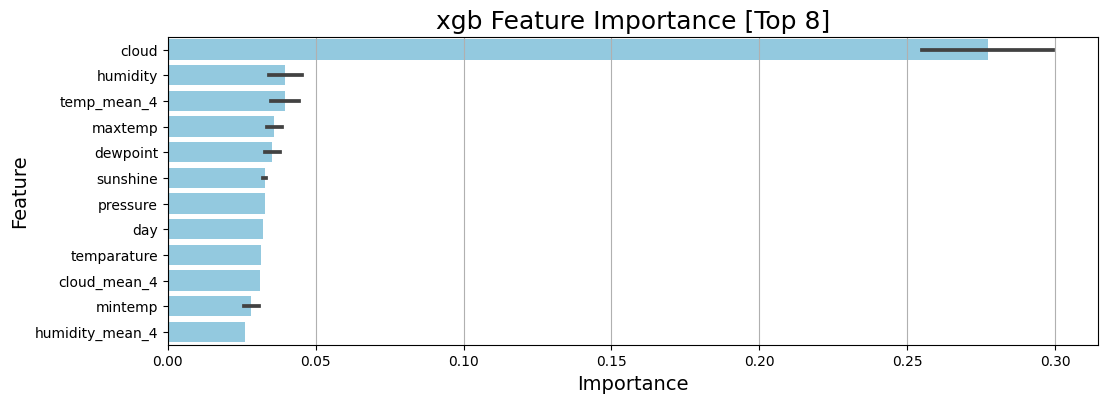

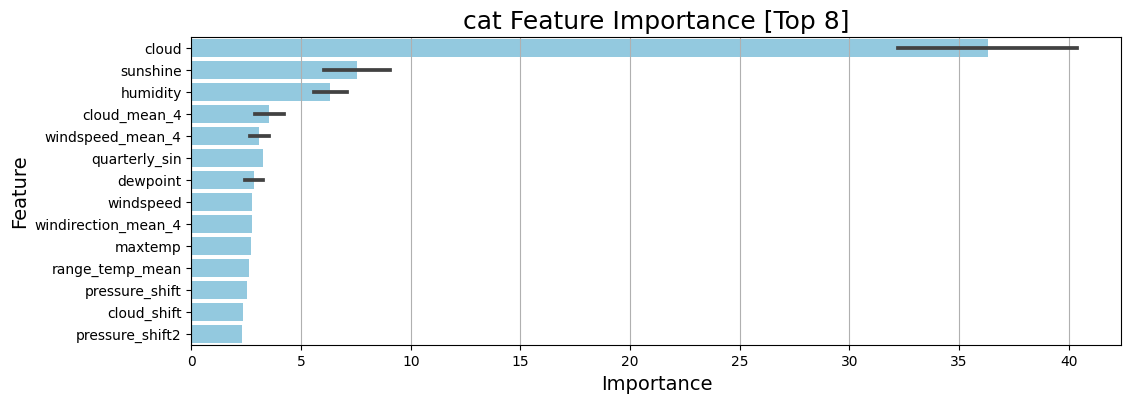

In [18]:
def visualize_importance(models, feature_cols, title, top=8):
    importances = []
    feature_importance = pd.DataFrame()
    for i, model in enumerate(models):
        _df = pd.DataFrame()
        _df["importance"] = model.feature_importances_
        _df["feature"] = pd.Series(feature_cols)
        _df["fold"] = i
        _df = _df.sort_values('importance', ascending=False)
        _df = _df.head(top)
        feature_importance = pd.concat([feature_importance, _df], axis=0, ignore_index=True)
        
    feature_importance = feature_importance.sort_values('importance', ascending=False)
    # display(feature_importance.groupby(["feature"]).mean().reset_index().drop('fold', axis=1))
    plt.figure(figsize=(12, 4))
    sns.barplot(x='importance', y='feature', data=feature_importance, color='skyblue', errorbar='sd')
    plt.xlabel('Importance', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    plt.title(f'{title} Feature Importance [Top {top}]', fontsize=18)
    plt.grid(True, axis='x')
    plt.show()
    
for name, models in trained_models.items():
    if name in ['cat', 'xgb']:
        visualize_importance(models, list(df_train_columns), name)

# Submission

In [19]:
df_sub['rainfall'] = np.median(np.array(test_predss_proba), axis=0)
df_sub.to_csv('submission.csv')
df_sub.head(5)

,id,rainfall
0,2190,0.932285
1,2191,0.939443
2,2192,0.870095
3,2193,0.294979
4,2194,0.237879


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='rainfall', ylabel='Count'>

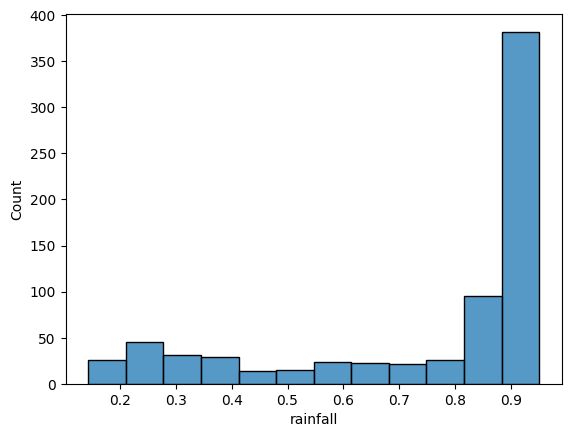

In [20]:
sns.histplot(df_sub['rainfall'])